# Customer Retention & Cohort Analysis

Analyzing customer retention behavior using cohort analysis to understand how engagement evolves over time and identify opportunities to improve long‑term retention.
## Objective

The goal of this project is to analyze customer retention patterns in an e‑commerce dataset using cohort analysis.

Key questions:

• How many customers return after their first purchase?  
• How does retention change over time?  
• Do newer cohorts retain better than earlier cohorts?  
• How quickly do customers churn?

## Dataset

Online Retail Transaction Dataset

This dataset contains transactional data from an online retail store including:

• InvoiceNo – transaction ID  
• StockCode – product identifier  
• Description – product name  
• Quantity – number of items purchased  
• InvoiceDate – transaction timestamp  
• UnitPrice – price per item  
• CustomerID – customer identifier  
• Country – customer location

### Import libraries, Load & Inspect the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/online_retail.csv", encoding="ISO-8859-1")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### Data Cleaning

In [6]:
# remove rows without customer id
df = df.dropna(subset=["CustomerID"])

# convert date
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Phase 1 - Customer Acquisition Analysis

In [10]:
# Identify each customer's first purchase date
first_purchase = df.groupby("CustomerID")["InvoiceDate"].min()

df["FirstPurchaseDate"] = df["CustomerID"].map(first_purchase)

In [11]:
df[["CustomerID","InvoiceDate","FirstPurchaseDate"]].head()

,CustomerID,InvoiceDate,FirstPurchaseDate
0,17850.0,2010-12-01 08:26:00,2010-12-01 08:26:00
1,17850.0,2010-12-01 08:26:00,2010-12-01 08:26:00
2,17850.0,2010-12-01 08:26:00,2010-12-01 08:26:00
3,17850.0,2010-12-01 08:26:00,2010-12-01 08:26:00
4,17850.0,2010-12-01 08:26:00,2010-12-01 08:26:00


In [12]:
# convert first purchase date into cohort month
df["CohortMonth"] = df["FirstPurchaseDate"].dt.to_period("M")

# Calculate how many new customers joined each month
new_customers = df.groupby("CohortMonth")["CustomerID"].nunique()

In [13]:
new_customers.head()

CohortMonth
2010-12    948
2011-01    421
2011-02    380
2011-03    440
2011-04    299
Freq: M, Name: CustomerID, dtype: int64

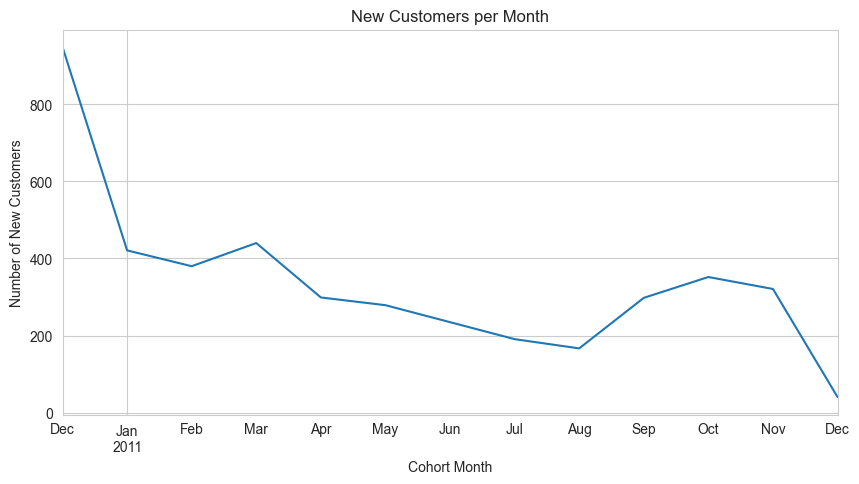

In [14]:
# New customers over time
plt.figure(figsize=(10,5))

new_customers.plot()

plt.title("New Customers per Month")
plt.xlabel("Cohort Month")
plt.ylabel("Number of New Customers")

plt.show()

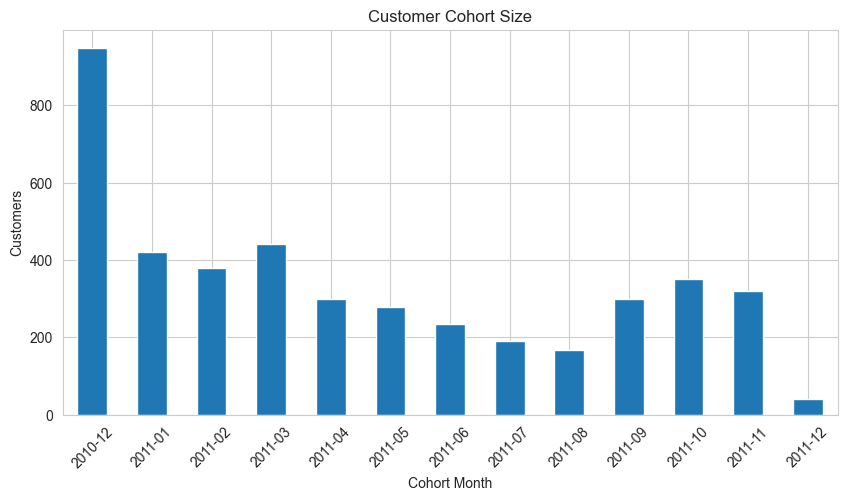

In [15]:
# Cohort Size
plt.figure(figsize=(10,5))

new_customers.plot(kind="bar")

plt.title("Customer Cohort Size")
plt.xlabel("Cohort Month")
plt.ylabel("Customers")

plt.xticks(rotation=45)

plt.show()

## Phase 1 - Customer Aquisition Insights
- Customer acquisition peaked in December 2010 (~950 new customers), likely driven by holiday demand.

- New customer growth declined through mid‑2011, reaching the lowest levels around July–August.

- Acquisition recovered slightly in late 2011 (Sep–Nov), suggesting renewed customer activity.

- The very small cohort in December 2011 likely reflects incomplete data rather than a true drop in customers.

## Phase 2 - Customer Retention (Cohort Analysis)
Objective: Analyze how many customers return to make purchases in later months after their first purchase.

In [19]:
# Create Purchase Month
df["PurchaseMonth"] = df["InvoiceDate"].dt.to_period("M")

In [20]:
# Measure how many months after the first purchase 
df["CohortIndex"] = (
    df["PurchaseMonth"] - df["CohortMonth"]
).apply(lambda x: x.n)

In [22]:
# Count unique customers per cohort per month.
cohort_data = df.groupby(
    ["CohortMonth", "CohortIndex"]
)["CustomerID"].nunique()

cohort_table = cohort_data.unstack()

In [23]:
cohort_table.head()

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,948.0,362.0,317.0,367.0,341.0,376.0,360.0,336.0,336.0,374.0,354.0,474.0,260.0
2011-01,421.0,101.0,119.0,102.0,138.0,126.0,110.0,108.0,131.0,146.0,155.0,63.0,NaN
2011-02,380.0,94.0,73.0,106.0,102.0,94.0,97.0,107.0,98.0,119.0,35.0,NaN,NaN
2011-03,440.0,84.0,112.0,96.0,102.0,78.0,116.0,105.0,127.0,39.0,NaN,NaN,NaN
2011-04,299.0,68.0,66.0,63.0,62.0,71.0,69.0,78.0,25.0,NaN,NaN,NaN,NaN


In [24]:
# Calculate retention rate
cohort_size = cohort_table.iloc[:,0]

retention = cohort_table.divide(cohort_size, axis=0)

In [25]:
retention.head()

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,1.0,0.381857,0.334388,0.387131,0.359705,0.396624,0.379747,0.354430,0.354430,0.394515,0.373418,0.500000,0.274262
2011-01,1.0,0.239905,0.282660,0.242280,0.327791,0.299287,0.261283,0.256532,0.311164,0.346793,0.368171,0.149644,NaN
2011-02,1.0,0.247368,0.192105,0.278947,0.268421,0.247368,0.255263,0.281579,0.257895,0.313158,0.092105,NaN,NaN
2011-03,1.0,0.190909,0.254545,0.218182,0.231818,0.177273,0.263636,0.238636,0.288636,0.088636,NaN,NaN,NaN
2011-04,1.0,0.227425,0.220736,0.210702,0.207358,0.237458,0.230769,0.260870,0.083612,NaN,NaN,NaN,NaN


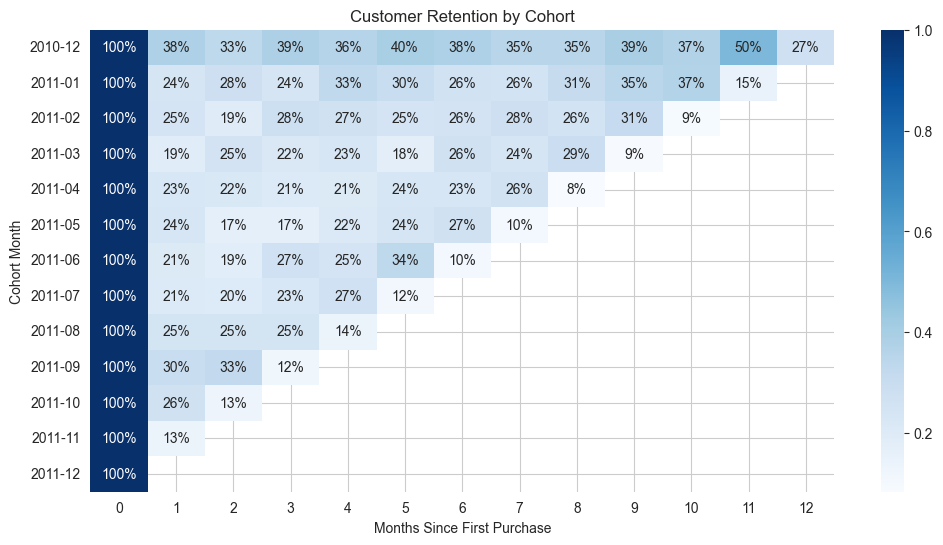

In [26]:
# Retention heatmap
plt.figure(figsize=(12,6))

sns.heatmap(
    retention,
    annot=True,
    fmt=".0%",
    cmap="Blues"
)

plt.title("Customer Retention by Cohort")
plt.ylabel("Cohort Month")
plt.xlabel("Months Since First Purchase")

plt.show()

## Phase 2 — Customer Retention Insights
- Customer retention drops significantly after the first month, with most cohorts retaining around 20–40% of customers in month 1.

- Retention gradually declines over time, indicating that many customers make only one or a few purchases before becoming inactive.

- Some cohorts (such as the December 2010 cohort) show relatively stronger long‑term retention compared to later cohorts.

- Overall, the heatmap suggests that customer churn occurs quickly, highlighting the importance of improving early customer engagement and repeat purchase incentives.

## Phase 3 — Revenue Retention / Customer Value
Objective: Analyze how revenue from each cohort evolves over time and identify which cohorts are the most valuable.

In [27]:
# Group revenue by cohort month and cohort index.
cohort_revenue = df.groupby(
    ["CohortMonth", "CohortIndex"]
)["Revenue"].sum()

cohort_revenue_table = cohort_revenue.unstack()

In [28]:
cohort_revenue_table.head()

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,554604.020,271616.52,230856.22,302509.39,200927.98,321611.71,312894.36,303907.31,310882.670,466580.68,438835.91,510982.23,182814.95
2011-01,203457.860,56168.55,62264.88,41516.17,82313.31,84009.54,70218.50,72886.27,74430.631,104181.16,122027.20,27850.51,NaN
2011-02,149521.380,25260.26,37456.25,45852.34,35666.69,31081.74,47665.32,55840.13,51861.550,60544.86,9366.67,NaN,NaN
2011-03,189930.080,26383.20,53693.95,40324.05,46759.97,38360.36,60622.28,61705.53,65303.870,11252.28,NaN,NaN,NaN
2011-04,119764.251,28921.03,24928.06,23892.08,26006.54,29653.29,28223.83,33889.78,6292.000,NaN,NaN,NaN,NaN


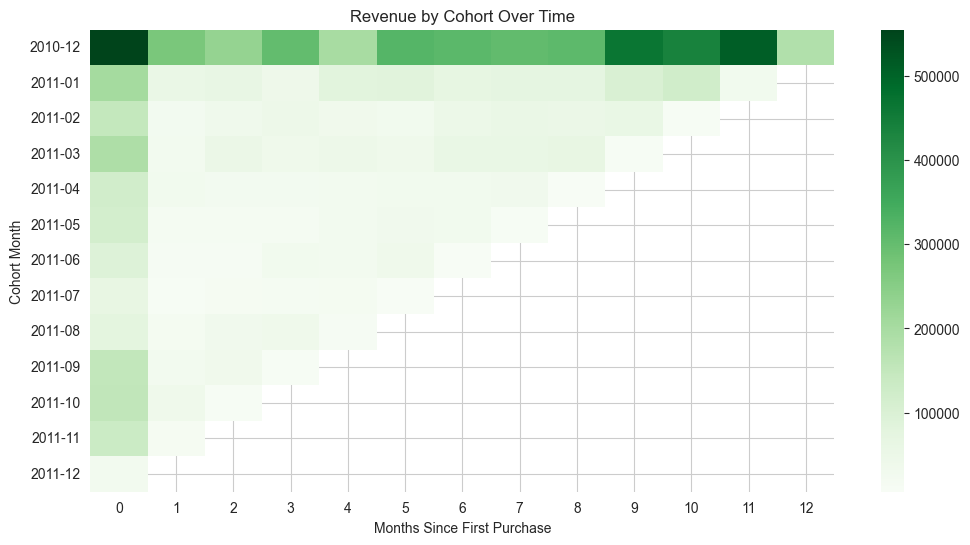

In [29]:
# Revenue Heatmap
plt.figure(figsize=(12,6))

sns.heatmap(
    cohort_revenue_table,
    cmap="Greens"
)

plt.title("Revenue by Cohort Over Time")
plt.ylabel("Cohort Month")
plt.xlabel("Months Since First Purchase")

plt.show()

In [30]:
# Revenue per customer - normalize revenue by cohort size
revenue_per_customer = cohort_revenue_table.divide(cohort_size, axis=0)

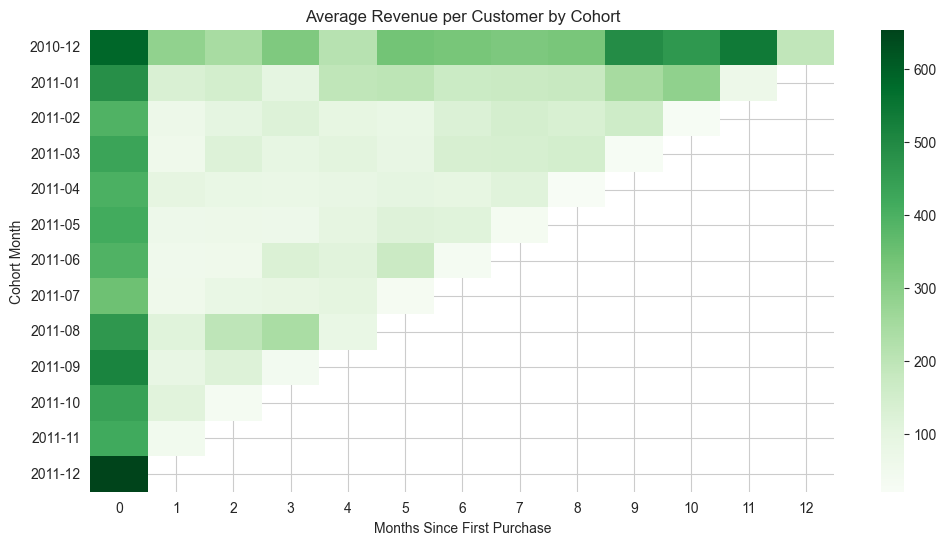

In [31]:
plt.figure(figsize=(12,6))

sns.heatmap(
    revenue_per_customer,
    cmap="Greens"
)

plt.title("Average Revenue per Customer by Cohort")
plt.ylabel("Cohort Month")
plt.xlabel("Months Since First Purchase")

plt.show()

## Phase 3 — Key Insights

- Early cohorts generate the highest total revenue due to their longer activity period.

- Revenue contribution declines over time as fewer customers remain active in later months.

- Average revenue per customer is highest in the early months after acquisition, suggesting customers spend most shortly after their first purchase.

